# Домашнее задание "Продвинутая оптимизация".

При фиксированном `seed=42` поэкспериментируйте с параметрами алгоритма [differential_evolution](https://docs.scipy.org/doc/scipy/reference/generated/scipy.optimize.differential_evolution.html): strategy, popsize, mutation.

Постройте графики количества итераций (`nit`) оптимизации [функции ackley](https://en.wikipedia.org/wiki/Ackley_function) от значения параметра. 

In [29]:
import numpy as np
from scipy.optimize import differential_evolution
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

%matplotlib inline

In [28]:
def ackley(x):
    arg1 = -0.2 * np.sqrt(0.5 * (x[0] ** 2 + x[1] ** 2))
    arg2 = 0.5 * (np.cos(2. * np.pi * x[0]) + np.cos(2. * np.pi * x[1]))
    return -20. * np.exp(arg1) - np.exp(arg2) + 20. + np.e

bounds = [(-10, 10), (-10, 10)]

results = []

strategies = [
    'best1bin', 'best1exp', 'rand1bin', 'rand1exp',
    'rand2bin', 'rand2exp', 'best2bin', 'best2exp',
    'currenttobest1bin', 'currenttobest1exp',
    'randtobest1bin', 'randtobest1exp'
]

for _ in range(20):
    strategy = np.random.choice(strategies)
    popsize = np.random.randint(5, 15)
    mutation = np.random.uniform(0.5, 1.5)
    result = differential_evolution(ackley, bounds, seed=42, strategy=strategy, popsize=popsize, mutation=mutation)
    results.append({'strategy': strategy, 'popsize': popsize, 'mutation': mutation, 'nit': result.nit})
    
df = pd.DataFrame(results)

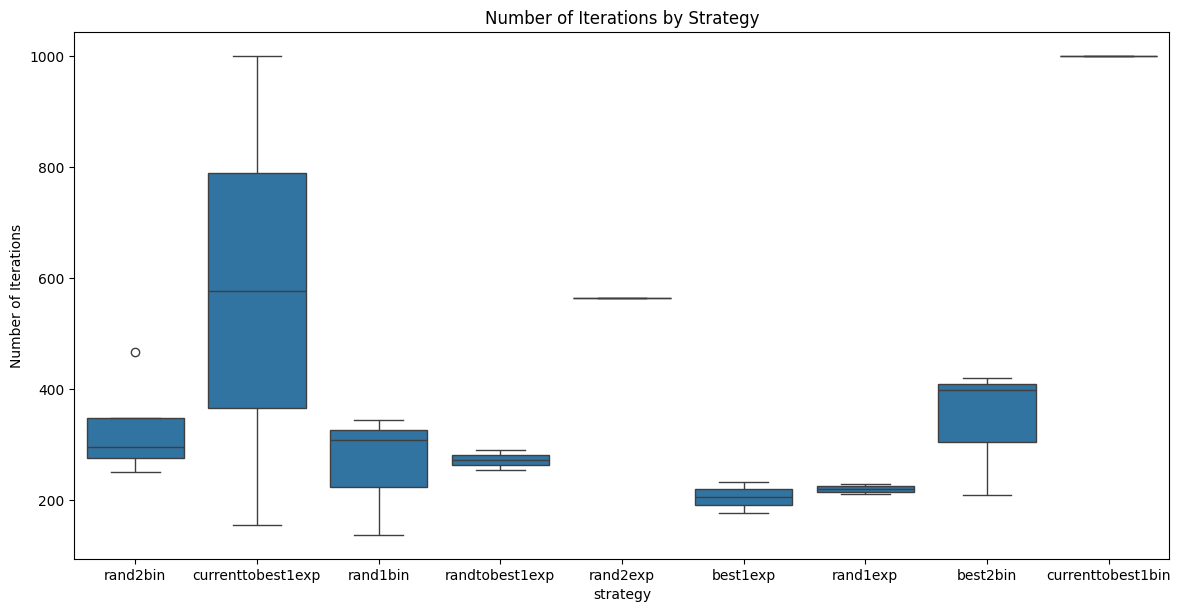

In [36]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x='strategy', y='nit')
plt.tight_layout()
plt.title('Number of Iterations by Strategy')
plt.ylabel('Number of Iterations')
plt.show()


<Figure size 1200x600 with 0 Axes>

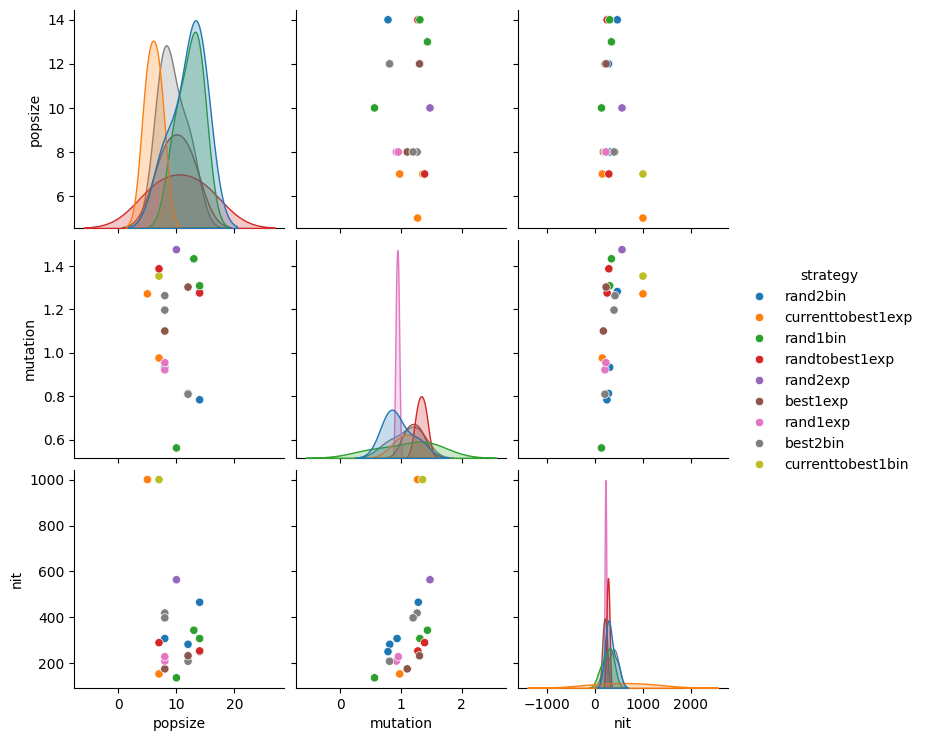

In [47]:
plt.figure(figsize=(12, 6))
sns.pairplot(df, vars=['popsize', 'mutation', 'nit'], hue='strategy')
plt.show()